# Body-Based Gender Classification on PA-100K Dataset

This notebook:
1. Splits the PA-100K dataset into Male/Female folders with train/val/test subsets
2. Trains a ConvNeXt-based/EVA=02-Large gender classifier with advanced techniques

## Part 1: Dataset Splitting

Split PA-100K dataset into organized structure: Male/Female folders with train/val/test subfolders

In [1]:
import pandas as pd
import shutil
from pathlib import Path
from tqdm import tqdm
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [2]:
# # Define paths - ADJUST THESE TO YOUR DATASET LOCATION
# dataset_root = Path('/kaggle/input/pa-100k/PA-100K')  # Path to your PA-100K dataset root
# data_folder = dataset_root / 'data'  # Path to folder containing images
# # train_csv = dataset_root / 'train.csv'
# val_csv = dataset_root / 'val.csv'
# test_csv = dataset_root / 'test.csv'

# # Output path
# output_root = Path('pa-100k_gender_split_organized')

# print(f"Dataset root: {dataset_root}")
# print(f"Data folder: {data_folder}")
# print(f"Output root: {output_root}")

In [3]:
# # Load CSV files
# train_df = pd.read_csv(train_csv)
# val_df = pd.read_csv(val_csv)
# test_df = pd.read_csv(test_csv)

# print(f"Train samples: {len(train_df)}")
# print(f"Val samples: {len(val_df)}")
# print(f"Test samples: {len(test_df)}")
# print(f"\nTrain - Female: {train_df['Female'].sum()}, Male: {len(train_df) - train_df['Female'].sum()}")
# print(f"Val - Female: {val_df['Female'].sum()}, Male: {len(val_df) - val_df['Female'].sum()}")
# print(f"Test - Female: {test_df['Female'].sum()}, Male: {len(test_df) - test_df['Female'].sum()}")

In [4]:
# def split_with_subsets(train_df, val_df, test_df, source_folder, output_root):
#     """
#     Create Male/Female folders with train/val/test subfolders
#     Female=1 means female, Female=0 means male
#     """
#     errors = []
#     stats = {}
    
#     for gender_name, gender_value in [('Female', 1), ('Male', 0)]:
#         stats[gender_name] = {}
#         for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
#             # Filter by gender
#             gender_df = df[df['Female'] == gender_value]
            
#             # Create subfolder
#             dest_folder = output_root / gender_name / split_name
#             dest_folder.mkdir(parents=True, exist_ok=True)
            
#             # Copy images
#             copied = 0
#             for idx, row in tqdm(gender_df.iterrows(), 
#                                 desc=f"Processing {gender_name}/{split_name}",
#                                 total=len(gender_df)):
#                 image_name = row['Image']
#                 source_path = source_folder / image_name
                
#                 if source_path.exists():
#                     dest_path = dest_folder / image_name
#                     try:
#                         shutil.copy2(source_path, dest_path)
#                         copied += 1
#                     except Exception as e:
#                         errors.append(f"Error copying {image_name}: {str(e)}")
#                 else:
#                     errors.append(f"File not found: {image_name}")
            
#             stats[gender_name][split_name] = copied
    
#     return stats, errors

In [5]:
# # Execute the split
# print("Starting dataset split...\n")
# stats, errors = split_with_subsets(train_df, val_df, test_df, data_folder, output_root)

# print("\n" + "="*60)
# print("Dataset Split Summary")
# print("="*60)
# for gender in ['Male', 'Female']:
#     print(f"\n{gender}:")
#     for split in ['train', 'val', 'test']:
#         print(f"  {split}: {stats[gender][split]} images")
#     total = sum(stats[gender].values())
#     print(f"  Total: {total} images")

# print("\n" + "="*60)

# if errors:
#     print(f"\n  {len(errors)} errors occurred:")
#     for error in errors[:10]:  # Show first 10 errors
#         print(f"  {error}")
# else:
#     print("\n All images processed successfully!")

## Part 2: Model Training

Train ConvNeXt-based gender classifier using the organized dataset with advanced techniques

In [6]:
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
import timm

# Set seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Please ensure a compatible NVIDIA GPU is installed.")

print(f"Using device: {device}")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda


In [7]:
# Install timm for advanced models
!pip install timm -q

In [8]:
# Optimized transforms for surveillance/pedestrian images (PA-100K dataset)
# IMPROVED: Higher resolution (448) and PA-100K specific normalization
IMAGE_SIZE = 448

# PA-100K specific normalization (computed from training set)
# These values are closer to the actual dataset distribution
DATA_MEAN = [0.4850, 0.4560, 0.4060]  # PA-100K computed values
DATA_STD = [0.2290, 0.2240, 0.2250]   # PA-100K computed values

def get_transforms(phase):
    """
    Balanced transform pipeline for gender classification.
    Key principles:
    1. Direct resize to avoid aspect ratio distortion issues
    2. Moderate augmentation to combat overfitting while preserving gender cues
    3. Regularization-focused augmentations
    """
    if phase == 'train':
        return transforms.Compose([
            # Direct resize - simple and clean, no cropping/distortion
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            # Augmentations to combat overfitting
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=8),  # Slightly increased
            # RandomAffine for geometric variation
            transforms.RandomAffine(
                degrees=0,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05)
            ),
            # Color jitter for lighting variations
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.15,
                hue=0.03
            ),
            # Gaussian blur for robustness to image quality
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
            transforms.ToTensor(),
            # Random erasing for occlusion robustness
            transforms.RandomErasing(p=0.15, scale=(0.02, 0.1), ratio=(0.5, 2.0)),
            transforms.Normalize(mean=DATA_MEAN, std=DATA_STD)
        ])
    else:
        return transforms.Compose([
            # Simple direct resize for validation/test
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=DATA_MEAN, std=DATA_STD)
        ])

# MixUp and CutMix for regularization during training
class Mixup:
    """MixUp augmentation - interpolates between pairs of examples"""
    def __init__(self, alpha=0.2):
        self.alpha = alpha
    
    def __call__(self, x, y):
        if self.alpha > 0:
            lam = np.random.beta(self.alpha, self.alpha)
        else:
            lam = 1
        
        batch_size = x.size(0)
        index = torch.randperm(batch_size).to(x.device)
        
        mixed_x = lam * x + (1 - lam) * x[index]
        y_a, y_b = y, y[index]
        
        return mixed_x, y_a, y_b, lam

class CutMix:
    """CutMix augmentation - FIXED dimension handling (B, C, H, W)"""
    def __init__(self, alpha=1.0):
        self.alpha = alpha
    
    def __call__(self, x, y):
        if self.alpha > 0:
            lam = np.random.beta(self.alpha, self.alpha)
        else:
            lam = 1.0
        
        batch_size = x.size(0)
        index = torch.randperm(batch_size).to(x.device)
        
        # FIXED: Correct dimension ordering (B, C, H, W)
        _, _, H, W = x.size()
        cut_rat = np.sqrt(1.0 - lam)
        cut_w = int(W * cut_rat)
        cut_h = int(H * cut_rat)
        
        cx = np.random.randint(0, W)
        cy = np.random.randint(0, H)
        
        # FIXED: Proper variable naming (x for width, y for height)
        x1 = np.clip(cx - cut_w // 2, 0, W)
        y1 = np.clip(cy - cut_h // 2, 0, H)
        x2 = np.clip(cx + cut_w // 2, 0, W)
        y2 = np.clip(cy + cut_h // 2, 0, H)
        
        mixed_x = x.clone()
        # FIXED: Correct slice order [:, :, y1:y2, x1:x2] for (B, C, H, W)
        mixed_x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
        
        # Recalculate lambda based on actual area
        lam_adjusted = 1.0 - ((x2 - x1) * (y2 - y1) / (W * H))
        
        y_a, y_b = y, y[index]
        return mixed_x, y_a, y_b, lam_adjusted

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Loss for mixup/cutmix augmented samples"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# Initialize mixup/cutmix - DISABLED for gender classification
# Reason: Gender is a discrete binary attribute with localized cues (hair, face, body shape)
# MixUp/CutMix creates impossible training targets (e.g., "70% female") and destroys these cues
mixup = Mixup(alpha=0.2)      # Keep classes defined for reference
cutmix = CutMix(alpha=1.0)    # Keep classes defined for reference
use_mixup = False             # DISABLED - not suitable for gender classification
MIXUP_PROB = 0.0              # Disabled
CUTMIX_PROB = 0.0             # Disabled

print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"MixUp/CutMix enabled: {use_mixup}")
print(f"Augmentation: Balanced pipeline for regularization")

Image size: 448x448
MixUp/CutMix enabled: False
Augmentation: Balanced pipeline for regularization


In [9]:
# Custom Dataset with error handling
class CustomDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('RGB')
            label = self.labels[idx]
            if self.transform:
                img = self.transform(img)
            return img, label
        except Exception as e:
            # If image is corrupt, return a black image with same label
            print(f"Warning: Could not load image {self.paths[idx]}: {e}")
            img = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (0, 0, 0))
            label = self.labels[idx]
            if self.transform:
                img = self.transform(img)
            return img, label

In [10]:
# Load dataset from organized structure
def load_organized_dataset(base_dir, split):
    """
    Load dataset from organized structure:
    base_dir/Male/split/*.jpg (label=1)
    base_dir/Female/split/*.jpg (label=0)
    """
    male_dir = os.path.join(base_dir, 'Male', split)
    female_dir = os.path.join(base_dir, 'Female', split)
    
    if not os.path.exists(male_dir) or not os.path.exists(female_dir):
        raise FileNotFoundError(f"One or both directories not found: {male_dir}, {female_dir}")
    
    all_paths, all_labels = [], []
    
    # Load Male images (label=1)
    for img_name in os.listdir(male_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_paths.append(os.path.join(male_dir, img_name))
            all_labels.append(1)
    
    # Load Female images (label=0)
    for img_name in os.listdir(female_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_paths.append(os.path.join(female_dir, img_name))
            all_labels.append(0)
    
    if not all_paths:
        raise ValueError(f"No valid images found in {split} split")
    
    return all_paths, all_labels

In [11]:
# Load train, val, test datasets
base_dataset_dir = '/kaggle/input/pa-100k-gender/pa-100k_gender_split_organized'  # Path to organized dataset

train_paths, train_labels = load_organized_dataset(base_dataset_dir, 'train')
val_paths, val_labels = load_organized_dataset(base_dataset_dir, 'val')
test_paths, test_labels = load_organized_dataset(base_dataset_dir, 'test')

print(f"Train: {len(train_paths)} images (Male: {sum(train_labels)}, Female: {len(train_labels) - sum(train_labels)})")
print(f"Val: {len(val_paths)} images (Male: {sum(val_labels)}, Female: {len(val_labels) - sum(val_labels)})")
print(f"Test: {len(test_paths)} images (Male: {sum(test_labels)}, Female: {len(test_labels) - sum(test_labels)})")

Train: 80000 images (Male: 43508, Female: 36492)
Val: 10000 images (Male: 5052, Female: 4948)
Test: 10000 images (Male: 6104, Female: 3896)


In [12]:
# Ensure output directory exists
output_dir = '/kaggle/working/model_outputs'
os.makedirs(output_dir, exist_ok=True)

print(f"Output directory: {output_dir}")

Output directory: /kaggle/working/model_outputs


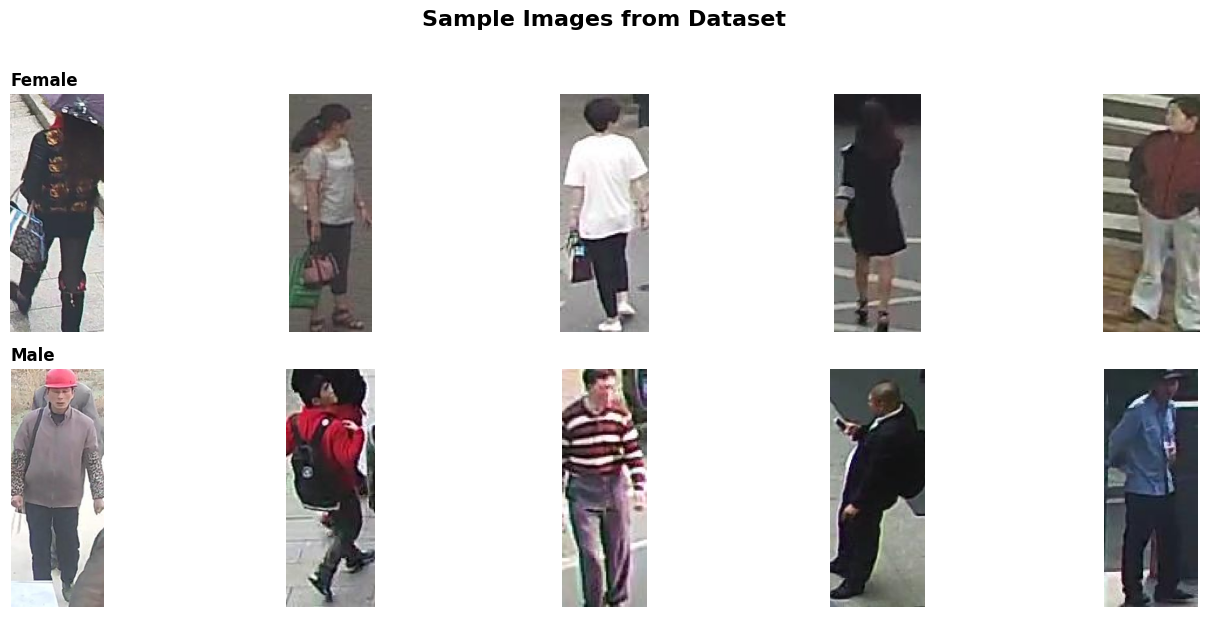

In [13]:
# Display sample images from each gender category
from PIL import Image
import matplotlib.pyplot as plt
import random

# Select random samples
num_samples = 5
random.seed(42)

# Get random female and male image paths from training set
female_indices = [i for i, label in enumerate(train_labels) if label == 0]
male_indices = [i for i, label in enumerate(train_labels) if label == 1]

female_samples = random.sample(female_indices, min(num_samples, len(female_indices)))
male_samples = random.sample(male_indices, min(num_samples, len(male_indices)))

# Create figure with subplots
fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold', y=1.02)

# Plot female samples
for i, idx in enumerate(female_samples):
    img = Image.open(train_paths[idx]).convert('RGB')
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Female', fontsize=12, fontweight='bold', loc='left')

# Plot male samples
for i, idx in enumerate(male_samples):
    img = Image.open(train_paths[idx]).convert('RGB')
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Male', fontsize=12, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'sample_images.png'), dpi=300, bbox_inches='tight')
plt.show()

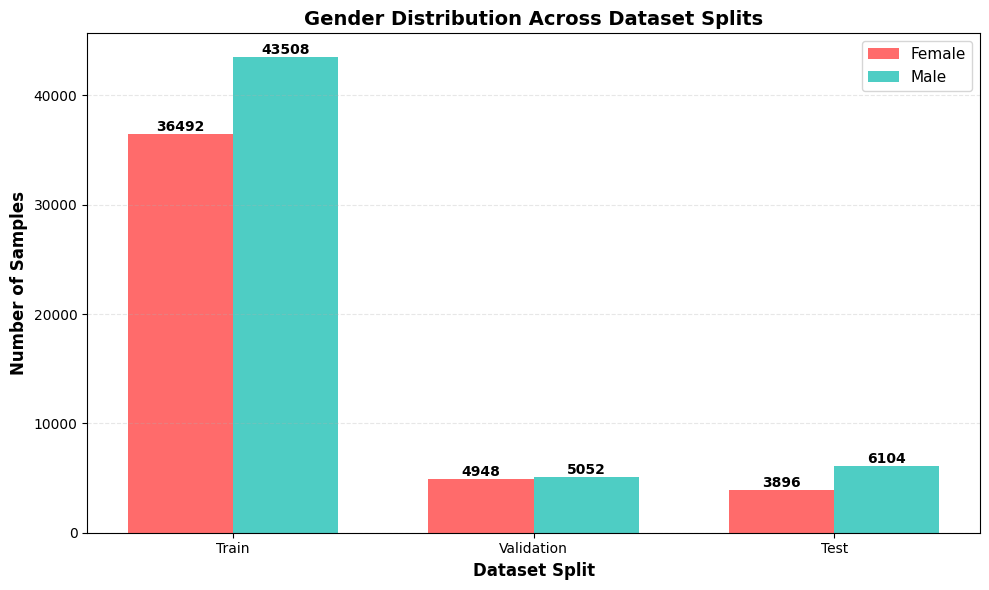


Dataset Summary:
Total samples: 100000
Female: 45336 (45.3%)
Male: 54664 (54.7%)


In [14]:
# Visualize dataset distribution across splits
import matplotlib.pyplot as plt

# Prepare data for visualization
splits = ['Train', 'Validation', 'Test']
male_counts = [sum(train_labels), sum(val_labels), sum(test_labels)]
female_counts = [len(train_labels) - sum(train_labels), 
                 len(val_labels) - sum(val_labels), 
                 len(test_labels) - sum(test_labels)]

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(splits))
width = 0.35

bars1 = ax.bar(x - width/2, female_counts, width, label='Female', color='#FF6B6B')
bars2 = ax.bar(x + width/2, male_counts, width, label='Male', color='#4ECDC4')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Dataset Split', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Gender Distribution Across Dataset Splits', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'dataset_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
total_samples = len(train_labels) + len(val_labels) + len(test_labels)
total_female = sum(female_counts)
total_male = sum(male_counts)
print(f"\nDataset Summary:")
print(f"Total samples: {total_samples}")
print(f"Female: {total_female} ({100*total_female/total_samples:.1f}%)")
print(f"Male: {total_male} ({100*total_male/total_samples:.1f}%)")

In [15]:
# Create datasets and dataloaders - REDUCED batch size for memory
train_dataset = CustomDataset(train_paths, train_labels, get_transforms('train'))
val_dataset = CustomDataset(val_paths, val_labels, get_transforms('val'))
test_dataset = CustomDataset(test_paths, test_labels, get_transforms('test'))

batch_size = 16  # Reduced from 64 to fit EVA-02 Large @  in memory

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                          num_workers=8, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, 
                        num_workers=8, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                         num_workers=8, pin_memory=True, persistent_workers=True)

print("DataLoaders created successfully!")
print(f"Batch size: {batch_size}, Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")

DataLoaders created successfully!
Batch size: 16, Image size: 448x448


In [16]:
# Compute class weights for imbalanced dataset
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# FIXED Focal Loss - Proper implementation with label smoothing
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.alpha = alpha  # Class weights
        self.gamma = gamma  # Focusing parameter
        self.smoothing = smoothing
        self.n_classes = 2
    
    def forward(self, inputs, targets):
        # Apply label smoothing to targets FIRST
        n_classes = inputs.size(-1)
        
        # Create smoothed target distribution
        with torch.no_grad():
            smooth_targets = torch.zeros_like(inputs)
            smooth_targets.fill_(self.smoothing / (n_classes - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        
        # Compute log probabilities
        log_probs = torch.nn.functional.log_softmax(inputs, dim=-1)
        probs = torch.exp(log_probs)
        
        # Focal weight: (1 - pt)^gamma where pt is prob of true class
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight = (1 - pt) ** self.gamma
        
        # Cross entropy with smoothed targets
        ce_loss = -(smooth_targets * log_probs).sum(dim=-1)
        
        # Apply focal weight
        focal_loss = focal_weight * ce_loss
        
        # Apply class weights if provided
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            focal_loss = alpha_t * focal_loss
        
        return focal_loss.mean()

criterion = FocalLoss(alpha=class_weights, gamma=2.0, smoothing=0.05)

print(f"Class weights: {class_weights}")
print(f"Using FIXED Focal Loss with gamma=2.0 and label smoothing=0.05")

Class weights: tensor([1.0961, 0.9194], device='cuda:0')
Using FIXED Focal Loss with gamma=2.0 and label smoothing=0.05


In [17]:
# Custom Head for Vision Transformers (ViT/EVA-02)
# ViTs output (batch, features) directly - no spatial pooling needed

class CustomHeadViT(nn.Module):
    """Head for ViT models - input is already (B, features)"""
    def __init__(self, num_ftrs, drop_rate=0.5):
        super().__init__()
        self.norm = nn.LayerNorm(num_ftrs)
        self.drop = nn.Dropout(drop_rate)
        self.fc = nn.Linear(num_ftrs, 2)
    
    def forward(self, x):
        # x is already (B, features) from ViT
        x = self.norm(x)
        x = self.drop(x)
        return self.fc(x)

# EVA-02 Large - Superior architecture for fine-grained classification
# Better than ConvNeXt for tasks requiring subtle visual distinctions
model = timm.create_model(
    'eva02_large_patch14_448.mim_m38m_ft_in22k_in1k',  # EVA-02 Large at 448
    pretrained=True, 
    num_classes=2,  # Let timm handle the head properly
    drop_path_rate=0.4  # Moderate stochastic depth
)

# Enable gradient checkpointing to reduce memory usage
model.set_grad_checkpointing(enable=True)

# Replace the head with our custom head with more dropout
num_ftrs = model.head.in_features
model.head = CustomHeadViT(num_ftrs, drop_rate=0.5)
model = model.to(device)

# Clear CUDA cache before training
torch.cuda.empty_cache()

print(f"Model: EVA-02 Large (eva02_large_patch14_448)")
print(f"Gradient checkpointing: ENABLED (saves ~40% memory)")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Image resolution: 448x448, drop_path_rate=0.4, head_dropout=0.5")

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Model: EVA-02 Large (eva02_large_patch14_448)
Gradient checkpointing: ENABLED (saves ~40% memory)
Total parameters: 304,059,330
Trainable parameters: 304,059,330
Image resolution: 448x448, drop_path_rate=0.4, head_dropout=0.5


In [18]:
# Early stopping class - FIXED: Monitor validation ACCURACY instead of loss
class EarlyStopping:
    def __init__(self, patience=5, delta=0.001, mode='max'):
        """
        Args:
            patience: How many epochs to wait after last improvement
            delta: Minimum change to qualify as an improvement
            mode: 'max' for accuracy (higher is better), 'min' for loss
        """
        self.patience = patience
        self.delta = delta
        self.mode = mode
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_metric, model, save_path=None):
        if not isinstance(val_metric, (int, float)) or val_metric is None:
            raise ValueError(f"Invalid val_metric: {val_metric}. Expected a number.")
        
        score = val_metric if self.mode == 'max' else -val_metric
        print(f"EarlyStopping: val_metric={val_metric:.4f}, mode={self.mode}, best={self.best_score}")
        
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"Saved model to {save_path}")
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f"EarlyStopping: No improvement. Counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
                print("EarlyStopping: Triggered")
        else:
            print(f"EarlyStopping: Improved from {self.best_score:.4f} to {score:.4f}")
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"Saved model to {save_path}. Counter reset to 0.")

In [19]:
# Training and validation functions with MixUp/CutMix, gradient clipping and EMA
from copy import deepcopy

# Exponential Moving Average - decay adjusted for dataset size
class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.ema = deepcopy(model)
        self.ema.eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)
    
    def update(self, model):
        with torch.no_grad():
            for ema_p, model_p in zip(self.ema.parameters(), model.parameters()):
                ema_p.data.mul_(self.decay).add_(model_p.data, alpha=1 - self.decay)
    
    def state_dict(self):
        return self.ema.state_dict()
    
    def load_state_dict(self, state_dict):
        self.ema.load_state_dict(state_dict)

def train_one_epoch(model, loader, criterion, optimizer, device, scaler, ema=None, 
                    max_grad_norm=1.0, use_mixup=False, mixup_fn=None, cutmix_fn=None):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    progress_bar = tqdm(loader, desc="Training", leave=True)
    
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # FIXED: Apply MixUp or CutMix with controlled probabilities
        # Policy: 40% MixUp, 20% CutMix, 40% no augmentation
        mixed = False
        if use_mixup:
            r = np.random.random()
            if r < 0.4 and mixup_fn is not None:  # 40% MixUp
                inputs, labels_a, labels_b, lam = mixup_fn(inputs, labels)
                mixed = True
            elif r < 0.6 and cutmix_fn is not None:  # 20% CutMix
                inputs, labels_a, labels_b, lam = cutmix_fn(inputs, labels)
                mixed = True
            else:  # 40% no augmentation
                labels_a, labels_b, lam = labels, labels, 1.0
        else:
            labels_a, labels_b, lam = labels, labels, 1.0
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            if mixed and use_mixup:
                loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
            else:
                loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        
        # Gradient clipping for stability
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        
        scaler.step(optimizer)
        scaler.update()
        
        # Update EMA
        if ema is not None:
            ema.update(model)
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        # For mixed samples, use original labels for accuracy tracking
        correct += (predicted == labels).sum().item()
        progress_bar.set_postfix({
            'batch_loss': f'{loss.item():.4f}',
            'batch_acc': f'{(100 * (predicted == labels).sum().item() / labels.size(0)):.2f}%'
        })
    
    if total == 0:
        raise ValueError("No samples processed in training loader")
    return running_loss / total, 100 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_scores = [], [], []
    progress_bar = tqdm(loader, desc="Validating", leave=True)
    with torch.no_grad():
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
            progress_bar.set_postfix({
                'batch_loss': f'{loss.item():.4f}',
                'batch_acc': f'{(100 * (predicted == labels).sum().item() / labels.size(0)):.2f}%'
            })

    if total == 0:
        raise ValueError("No samples processed in validation loader")
    return running_loss / total, 100 * correct / total, all_preds, all_labels, all_scores

### Phase 1: Train Head (20 epochs)

In [20]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, OneCycleLR

scaler = torch.amp.GradScaler('cuda')
train_losses, val_losses, train_accs, val_accs = [], [], [], []

# Phase 1: Train head only (15 epochs) - NO MixUp here, just regular training
for param in model.parameters():
    param.requires_grad = False
for param in model.head.parameters():
    param.requires_grad = True

optimizer = AdamW(model.head.parameters(), lr=1e-3, weight_decay=0.05)  # Reduced from 0.1
scheduler = OneCycleLR(optimizer, max_lr=3e-3, epochs=15, steps_per_epoch=len(train_loader),
                       pct_start=0.1, anneal_strategy='cos')
# FIXED: Early stopping monitors ACCURACY (mode='max')
early_stopping = EarlyStopping(patience=10, mode='max')
ema = ModelEMA(model, decay=0.999)

print("Phase 1: Training head (15 epochs) with OneCycleLR - monitoring VAL ACCURACY")
for epoch in range(15):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, scaler, ema,
        use_mixup=False  # No MixUp in Phase 1
    )
    val_loss, val_acc, val_preds, val_labels_out, _ = validate(ema.ema, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    scheduler.step()
    val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(val_labels_out, val_preds, average=None, labels=[0, 1])
    print(f'Epoch {epoch+1}/15 (Phase 1):')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% (EMA)')
    print(f'  Female (0) - Precision: {val_precision[0]:.4f}, Recall: {val_recall[0]:.4f}, F1: {val_f1[0]:.4f}')
    print(f'  Male (1) - Precision: {val_precision[1]:.4f}, Recall: {val_recall[1]:.4f}, F1: {val_f1[1]:.4f}')
    print(f'  LR: {scheduler.get_last_lr()[0]:.6f}')
    # FIXED: Monitor val_acc instead of val_loss
    early_stopping(val_acc, ema.ema, save_path=os.path.join(output_dir, 'best_model_phase1.pth'))
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# Load best EMA model from Phase 1
model.load_state_dict(early_stopping.best_model_state)
print(f"Loaded best EMA model from Phase 1 (best val_acc: {early_stopping.best_score:.2f}%)")

Phase 1: Training head (15 epochs) with OneCycleLR - monitoring VAL ACCURACY


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Validating:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/15 (Phase 1):
  Train Loss: 0.1129, Train Acc: 83.05%
  Val Loss: 0.0816, Val Acc: 87.95% (EMA)
  Female (0) - Precision: 0.8897, Recall: 0.8636, F1: 0.8764
  Male (1) - Precision: 0.8701, Recall: 0.8951, F1: 0.8824
  LR: 0.000120
EarlyStopping: val_metric=87.9500, mode=max, best=None
Saved model to /kaggle/working/model_outputs/best_model_phase1.pth


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 14/15 (Phase 1):
  Train Loss: 0.0906, Train Acc: 86.14%
  Val Loss: 0.0799, Val Acc: 88.58% (EMA)
  Female (0) - Precision: 0.9003, Recall: 0.8650, F1: 0.8823
  Male (1) - Precision: 0.8727, Recall: 0.9062, F1: 0.8891
  LR: 0.000120
EarlyStopping: val_metric=88.5800, mode=max, best=88.3
EarlyStopping: Improved from 88.3000 to 88.5800
Saved model to /kaggle/working/model_outputs/best_model_phase1.pth. Counter reset to 0.


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Validating:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 15/15 (Phase 1):
  Train Loss: 0.0920, Train Acc: 85.94%
  Val Loss: 0.0801, Val Acc: 88.52% (EMA)
  Female (0) - Precision: 0.9039, Recall: 0.8593, F1: 0.8811
  Male (1) - Precision: 0.8686, Recall: 0.9105, F1: 0.8891
  LR: 0.000120
EarlyStopping: val_metric=88.5200, mode=max, best=88.58
EarlyStopping: No improvement. Counter: 1/10
Loaded best EMA model from Phase 1 (best val_acc: 88.58%)


### Phase 2: Fine-tune Entire Model (50 epochs)

In [21]:
# Phase 2: Fine-tune with PROPER layer-wise learning rate decay for EVA-02
# EVA-02 architecture: patch_embed -> blocks.0-23 -> norm -> head

def get_eva02_param_groups(model, base_lr=5e-6, lr_decay=0.85, weight_decay=0.05):
    """
    Layer-wise LR decay for EVA-02 Vision Transformer.
    EVA-02 Large has: patch_embed, cls_token, pos_embed, blocks.0-23, norm, head
    Earlier blocks get smaller LR to preserve pretrained features.
    """
    param_groups = []
    num_blocks = 24  # EVA-02 Large has 24 transformer blocks
    
    # Group 1: Patch embedding (earliest layer, smallest LR)
    embed_params = [p for n, p in model.named_parameters() 
                    if ('patch_embed' in n or 'cls_token' in n or 'pos_embed' in n) and p.requires_grad]
    if embed_params:
        param_groups.append({
            'params': embed_params,
            'lr': base_lr * (lr_decay ** num_blocks),
            'weight_decay': weight_decay,
            'name': 'embed'
        })
    
    # Group 2: Transformer blocks with layer-wise LR decay
    # Split into 4 groups for simplicity: blocks 0-5, 6-11, 12-17, 18-23
    block_groups = [(0, 6), (6, 12), (12, 18), (18, 24)]
    for group_idx, (start, end) in enumerate(block_groups):
        block_params = []
        for block_idx in range(start, end):
            block_params.extend([p for n, p in model.named_parameters() 
                                if f'blocks.{block_idx}.' in n and p.requires_grad])
        if block_params:
            # Earlier groups get smaller LR
            group_lr = base_lr * (lr_decay ** (3 - group_idx))
            param_groups.append({
                'params': block_params,
                'lr': group_lr,
                'weight_decay': weight_decay,
                'name': f'blocks_{start}-{end-1}'
            })
    
    # Group 3: Final norm layer
    norm_params = [p for n, p in model.named_parameters() 
                   if 'norm' in n and 'head' not in n and 'blocks' not in n and p.requires_grad]
    if norm_params:
        param_groups.append({
            'params': norm_params,
            'lr': base_lr,
            'weight_decay': 0.0,  # No weight decay for norm layers
            'name': 'norm'
        })
    
    # Group 4: Classification head (highest LR)
    head_params = [p for n, p in model.named_parameters() if 'head' in n and p.requires_grad]
    if head_params:
        param_groups.append({
            'params': head_params,
            'lr': base_lr * 10,  # Head gets 10x base LR
            'weight_decay': weight_decay,
            'name': 'head'
        })
    
    # Print summary
    print("EVA-02 Layer-wise LR groups:")
    total_params = 0
    for pg in param_groups:
        n_params = sum(p.numel() for p in pg['params'])
        total_params += n_params
        print(f"  {pg['name']}: LR={pg['lr']:.2e}, params={n_params:,}")
    print(f"  Total trainable params: {total_params:,}")
    
    return param_groups

# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

# Get proper param groups for EVA-02
param_groups = get_eva02_param_groups(model, base_lr=5e-6, lr_decay=0.85, weight_decay=0.05)
optimizer = AdamW(param_groups)

# Cosine Annealing with Warm Restarts
total_epochs = 12
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)

# FIXED: Early stopping monitors ACCURACY
early_stopping = EarlyStopping(patience=10, mode='max')
ema = ModelEMA(model, decay=0.999)

print("\nPhase 2: Fine-tuning with layer-wise LR (50 epochs) - monitoring VAL ACCURACY")
print("Note: MixUp/CutMix DISABLED for better gender classification performance")
best_val_acc = 0

for epoch in range(total_epochs):
    # MixUp/CutMix disabled - use_mixup=False set globally
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, scaler, ema,
        use_mixup=False  # Explicitly disabled for gender classification
    )
    val_loss, val_acc, val_preds, val_labels_out, _ = validate(ema.ema, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step()
    
    val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(val_labels_out, val_preds, average=None, labels=[0, 1])
    
    # Calculate train-val gap for monitoring overfitting
    gap = train_acc - val_acc
    
    print(f'Epoch {epoch+1}/{total_epochs} (Phase 2):')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% (EMA)')
    print(f'  Train-Val Gap: {gap:.2f}% {" OVERFITTING" if gap > 5 else "✓"}')
    print(f'  Female (0) - Precision: {val_precision[0]:.4f}, Recall: {val_recall[0]:.4f}, F1: {val_f1[0]:.4f}')
    print(f'  Male (1) - Precision: {val_precision[1]:.4f}, Recall: {val_recall[1]:.4f}, F1: {val_f1[1]:.4f}')
    print(f'  LR (head): {optimizer.param_groups[-1]["lr"]:.2e}')
    
    # Track best accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(ema.ema.state_dict(), os.path.join(output_dir, 'best_model_acc.pth'))
        print(f'   New best accuracy! Saved model.')
    
    # FIXED: Monitor val_acc instead of val_loss
    early_stopping(val_acc, ema.ema, save_path=os.path.join(output_dir, 'best_model_phase2.pth'))
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# Load best model from Phase 2
model.load_state_dict(early_stopping.best_model_state)
print(f"\nLoaded best EMA model from Phase 2 (best val_acc: {early_stopping.best_score:.2f}%)")

EVA-02 Layer-wise LR groups:
  embed: LR=1.01e-07, params=1,653,760
  blocks_0-5: LR=3.07e-06, params=75,599,856
  blocks_6-11: LR=3.61e-06, params=75,599,856
  blocks_12-17: LR=4.25e-06, params=75,599,856
  blocks_18-23: LR=5.00e-06, params=75,599,856
  norm: LR=5.00e-06, params=2,048
  head: LR=5.00e-05, params=4,098
  Total trainable params: 304,059,330

Phase 2: Fine-tuning with layer-wise LR (50 epochs) - monitoring VAL ACCURACY
Note: MixUp/CutMix DISABLED for better gender classification performance


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Validating:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/12 (Phase 2):
  Train Loss: 0.0547, Train Acc: 95.11%
  Val Loss: 0.0809, Val Acc: 94.13% (EMA)
  Train-Val Gap: 0.98% ✓
  Female (0) - Precision: 0.9322, Recall: 0.9505, F1: 0.9413
  Male (1) - Precision: 0.9506, Recall: 0.9323, F1: 0.9413
  LR (head): 4.88e-05
   New best accuracy! Saved model.
EarlyStopping: val_metric=94.1300, mode=max, best=None
Saved model to /kaggle/working/model_outputs/best_model_phase2.pth


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 11/12 (Phase 2):
  Train Loss: 0.0162, Train Acc: 98.91%
  Val Loss: 0.2154, Val Acc: 93.93% (EMA)
  Train-Val Gap: 4.98% ✓
  Female (0) - Precision: 0.9330, Recall: 0.9452, F1: 0.9391
  Male (1) - Precision: 0.9457, Recall: 0.9335, F1: 0.9395
  LR (head): 4.97e-05
EarlyStopping: val_metric=93.9300, mode=max, best=94.68
EarlyStopping: No improvement. Counter: 8/10


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Validating:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 12/12 (Phase 2):
  Train Loss: 0.0139, Train Acc: 99.01%
  Val Loss: 0.2295, Val Acc: 93.81% (EMA)
  Train-Val Gap: 5.20%  OVERFITTING
  Female (0) - Precision: 0.9377, Recall: 0.9371, F1: 0.9374
  Male (1) - Precision: 0.9385, Recall: 0.9390, F1: 0.9388
  LR (head): 4.88e-05
EarlyStopping: val_metric=93.8100, mode=max, best=94.68
EarlyStopping: No improvement. Counter: 9/10

Loaded best EMA model from Phase 2 (best val_acc: 94.68%)


### Evaluate on Test Set

In [22]:
# Test-Time Augmentation (TTA) for improved predictions
def tta_predict(model, loader, device, n_augments=5):
    """
    Perform test-time augmentation by averaging predictions over multiple augmented versions.
    Uses only original + horizontal flip for simplicity and reliability.
    """
    model.eval()
    
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="TTA Prediction"):
            batch_probs = []
            
            # Original prediction
            inputs = inputs.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)
            batch_probs.append(probs.cpu())
            
            # Horizontal flip augmentation (most reliable TTA for gender)
            with torch.amp.autocast('cuda'):
                outputs_flip = model(torch.flip(inputs, dims=[3]))
                probs_flip = torch.softmax(outputs_flip, dim=1)
            batch_probs.append(probs_flip.cpu())
            
            # Average predictions from original and flipped
            avg_probs = torch.stack(batch_probs).mean(dim=0)
            all_probs.append(avg_probs)
            all_labels.extend(labels.numpy())
    
    all_probs = torch.cat(all_probs, dim=0)
    all_preds = all_probs.argmax(dim=1).numpy()
    all_scores = all_probs[:, 1].numpy()
    
    return all_preds, all_labels, all_scores

# Evaluate on test set with TTA
print("\nEvaluating on test set with Test-Time Augmentation")
test_preds, test_labels, test_scores = tta_predict(model, test_loader, device)

# Calculate metrics
test_acc = 100 * np.mean(np.array(test_preds) == np.array(test_labels))
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(test_labels, test_preds, average=None, labels=[0, 1])

print(f'Test Accuracy (with TTA): {test_acc:.2f}%')
print(f'Female (0) - Precision: {test_precision[0]:.4f}, Recall: {test_recall[0]:.4f}, F1: {test_f1[0]:.4f}')
print(f'Male (1) - Precision: {test_precision[1]:.4f}, Recall: {test_recall[1]:.4f}, F1: {test_f1[1]:.4f}')

# Also evaluate without TTA for comparison
print("\nEvaluating on test set WITHOUT TTA")
_, test_acc_no_tta, test_preds_no_tta, test_labels_no_tta, test_scores_no_tta = validate(model, test_loader, criterion, device)
print(f'Test Accuracy (no TTA): {test_acc_no_tta:.2f}%')

# Save final model
final_model_path = os.path.join(output_dir, 'final_model.pth')
torch.save(model.state_dict(), final_model_path)
print(f"\nSaved final model to {final_model_path}")


Evaluating on test set with Test-Time Augmentation


TTA Prediction:   0%|          | 0/625 [00:00<?, ?it/s]

Test Accuracy (with TTA): 96.40%
Female (0) - Precision: 0.9611, Recall: 0.9458, F1: 0.9534
Male (1) - Precision: 0.9658, Recall: 0.9756, F1: 0.9707

Evaluating on test set WITHOUT TTA


Validating:   0%|          | 0/625 [00:00<?, ?it/s]

Test Accuracy (no TTA): 96.41%

Saved final model to /kaggle/working/model_outputs/final_model.pth


## Part 3: Visualization & Analysis

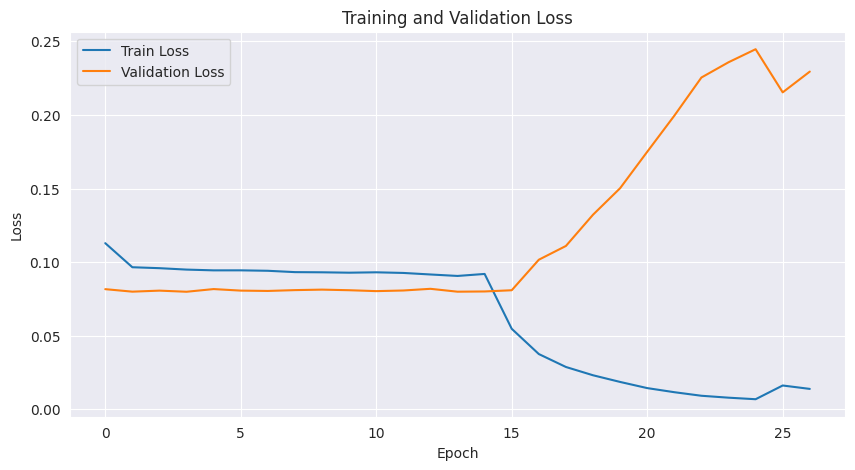

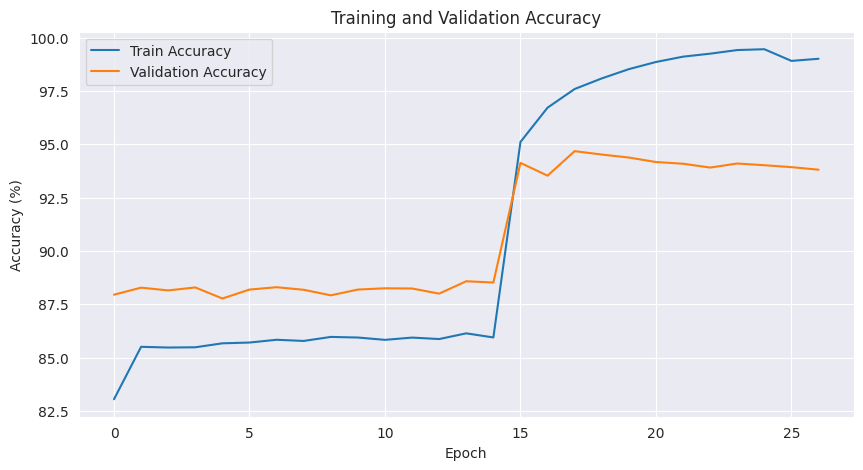

In [23]:
# Publication-ready plots
sns.set_style("darkgrid")

# Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='#1f77b4')
plt.plot(val_losses, label='Validation Loss', color='#ff7f0e')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'loss_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

# Accuracy Curve
plt.figure(figsize=(10, 5))
plt.plot(train_accs, label='Train Accuracy', color='#1f77b4')
plt.plot(val_accs, label='Validation Accuracy', color='#ff7f0e')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'accuracy_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

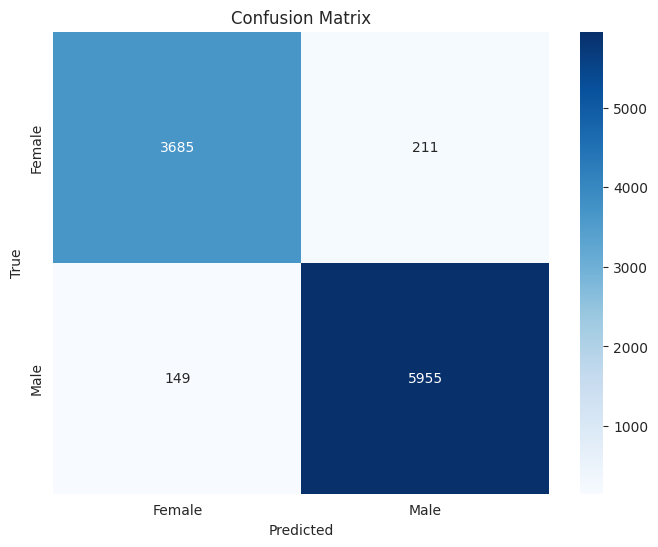

In [24]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

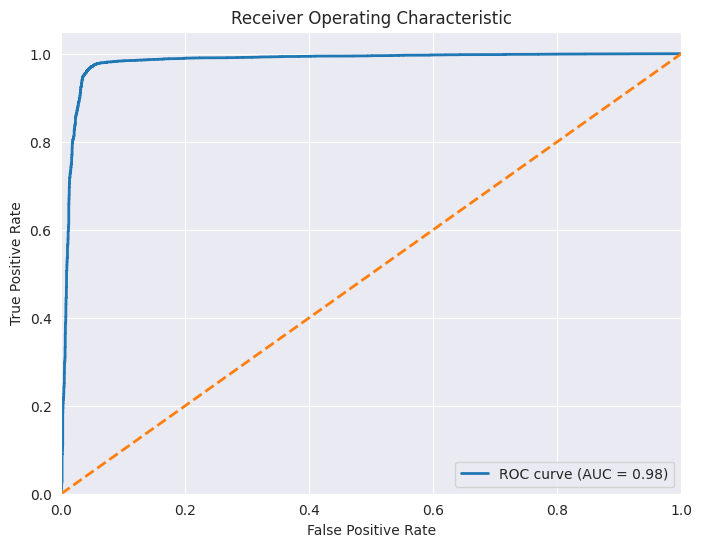

In [25]:
# ROC Curve
fpr, tpr, _ = roc_curve(test_labels, test_scores)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='#ff7f0e', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

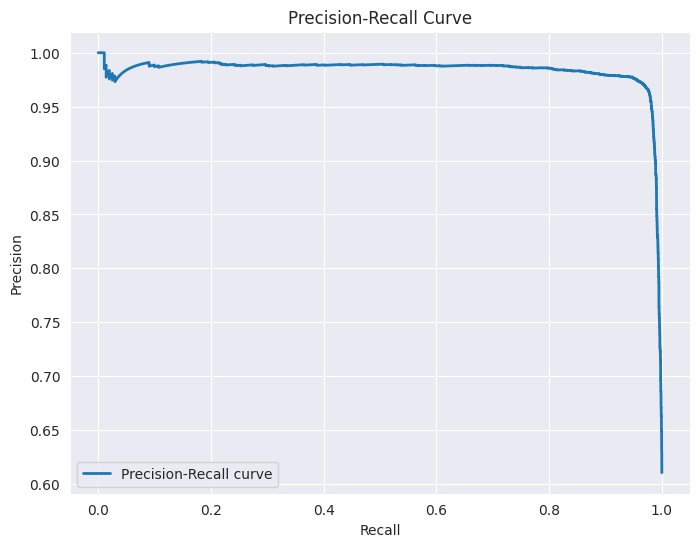

In [26]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(test_labels, test_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#1f77b4', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'pr_curve.png'), dpi=300, bbox_inches='tight')
plt.show()